# DAQ Emulators / Converters Test Notebook

This notebook verifies the functionality of the DAQ-as-AWG and DAQ-as-Oscilloscope emulators.
It works "out-of-the-box" using a `MockDaq` class, but you can easily swap this for a real DAQ driver to test with hardware.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we can import from src
src_path = os.path.abspath(os.path.join(os.getcwd(), '../../'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
    
from piec.drivers.daq.daq import Daq
from piec.drivers.emulators.daq_to_awg import DaqAsAwg
from piec.drivers.emulators.daq_to_oscilloscope import DaqAsOscilloscope

print(f"Added {src_path} to sys.path")

CacheLoader: Skipping SR830 (drivers.lockin.srs830.SRS830). Reason: No module named 'drivers'
--- Loaded driver registry from cache. ---
Added c:\Users\geofr\Desktop\Research\Coding\AntiGravity\piec\src to sys.path


## 1. Setup the DAQ Driver

Below is a `MockDaq` class for testing logic. 
**To test with a real instrument:** Comment out the Mock instantiation and instantiate your real driver.

In [2]:
# --- Mock DAQ for Logic Verification ---
class MockDaq(Daq):
    def __init__(self, address="MOCK"):
        # Bypass Instrument init for mock to avoid VISA errors
        self.output_state = {}
        self.ao_data = {}
        self.ai_config = {}
        self.resource_name = address

    def output(self, channel, on=True):
        self.output_state[channel] = on
        print(f"MockDaq: Output {channel} set to {on}")

    def write_AO(self, channel, data):
        self.ao_data[channel] = data
        print(f"MockDaq: Wrote {len(data)} points to AO {channel}")
        print(f"  -> Min: {np.min(data):.3f}, Max: {np.max(data):.3f}")

    def configure_AO_channel(self, channel, range, sample_rate):
        print(f"MockDaq: Configured AO {channel} with Range={range}, SR={sample_rate}")

    def configure_AI_channel(self, channel, range, sample_rate):
        self.ai_config[channel] = {'range': range, 'sample_rate': sample_rate}
        print(f"MockDaq: Configured AI {channel} with Range={range}, SR={sample_rate}")

    def read_AI(self, channel):
        # Return dummy sine wave data based on config
        points = 1000
        return np.sin(np.linspace(0, 10, points)) + np.random.normal(0, 0.1, points)

# =========================================================================
# INSTANTIATE DRIVER HERE
# =========================================================================

# Option A: Use Mock
daq_instrument = MockDaq()

# Option B: Use Real Instrument (Example)
# from piec.drivers.daq.mccdig import MCCDig # or your specific driver
# daq_instrument = MCCDig("USB0::...") 

print("DAQ Instrument initialized:", daq_instrument)

DAQ Instrument initialized: <__main__.MockDaq object at 0x00000156166638C0>


## 2. Test Emulator: DAQ as AWG (Arbitrary Waveform Generator)

This section wraps the DAQ driver in `DaqAsAwg` and configures it like a standard function generator.

In [3]:
# Wrap the DAQ
awg = DaqAsAwg(daq_instrument)

# Configure Waveform Parameters
channel = 1
freq = 1000 # Hz
amp = 2.0   # Vpp
offset = 0.0

awg.set_frequency(channel, freq)
awg.set_amplitude(channel, amp)
awg.set_offset(channel, offset)
awg.set_waveform(channel, 'SIN')

print(f"Configured Channel {channel}: {freq}Hz, {amp}Vpp Sine")

Error initializing instrument at EMULATED: VI_ERROR_INV_RSRC_NAME (-1073807342): Invalid resource reference specified. Parsing error.
Falling back to VIRTUAL mode.
INITIALIZING VIRTUAL RESOURCE MANAGER, VISA NOT CONNECTED
Configured Channel 1: 1000Hz, 2.0Vpp Sine


Enabling Output...
MockDaq: Configured AO 1 with Range=10, SR=1000000.0
MockDaq: Wrote 1000 points to AO 1
  -> Min: -1.000, Max: 1.000
MockDaq: Output 1 set to True


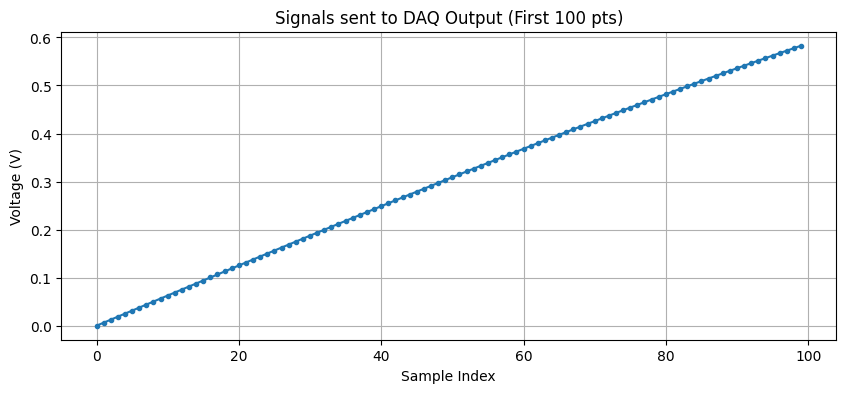

In [4]:
# Enable Output (Writes data to DAQ)
print("Enabling Output...")
awg.output(channel, True)

# Verify (if Mock)
if isinstance(daq_instrument, MockDaq):
    last_data = daq_instrument.ao_data.get(channel, [])
    if len(last_data) > 0:
        plt.figure(figsize=(10, 4))
        plt.plot(last_data[:100], '.-') # Plot first 100 points
        plt.title("Signals sent to DAQ Output (First 100 pts)")
        plt.xlabel("Sample Index")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.show()

## 3. Test Emulator: DAQ as Oscilloscope

This section wraps the DAQ driver in `DaqAsOscilloscope` and captures data.

In [5]:
# Wrap the DAQ
scope = DaqAsOscilloscope(daq_instrument)

# Configure Horizontal (Timebase)
tdiv = 1e-3 # 1 ms/div -> 10 ms total acquisition window
scope.set_horizontal_scale(tdiv)

# Configure Vertical
vdiv = 1.0 # 1 V/div
scope.set_vertical_scale(channel, vdiv)

# Set acquisition points (defines sample rate)
scope.set_acquisition_points(2000)

print(f"Configured Scope: {tdiv*1000} ms/div")

Error initializing instrument at EMULATED_SCOPE: VI_ERROR_INV_RSRC_NAME (-1073807342): Invalid resource reference specified. Parsing error.
Falling back to VIRTUAL mode.
INITIALIZING VIRTUAL RESOURCE MANAGER, VISA NOT CONNECTED
Configured Scope: 1.0 ms/div


Capturing data...
MockDaq: Configured AI 1 with Range=8.0, SR=200000.0
Captured 1000 points


,Time,Channel 1
0,0.00000,0.025185
1,0.00001,-0.040645
2,0.00002,-0.110343
3,0.00003,0.059617
4,0.00004,0.065532


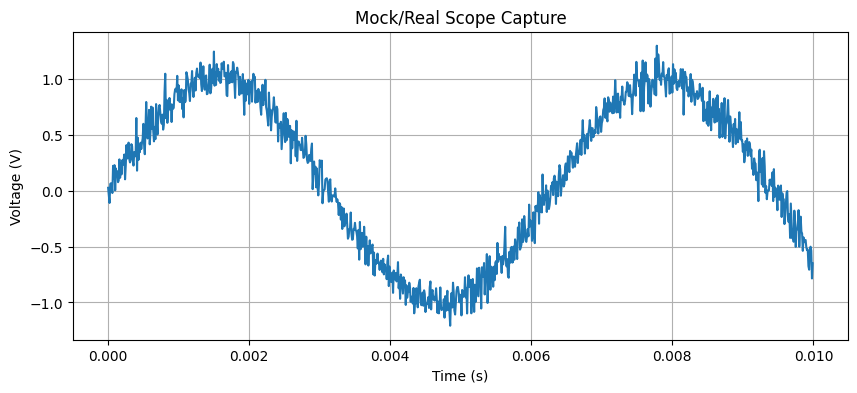

In [6]:
# Capture Data
print("Capturing data...")
df = scope.get_data()

# Display Results
print(f"Captured {len(df)} points")
display(df.head())

# Plot
if not df.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(df['Time'], df[f'Channel {channel}'])
    plt.title("Mock/Real Scope Capture")
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.grid(True)
    plt.show()